![WEkEO by Copernicus and Partners](https://github.com/wekeo/frameworks/blob/main/img/WEkEO_banner_EUMETSAT.png?raw=true)

<div style="display: flex; justify-content: space-between;">
  <a href="./01_WEkEOEarthkit_Introduction.ipynb">&lt;&lt; Introduction to the Earthkit WEkEO plugins</a>
  <a href="./README.md">README &gt;&gt;</a>
</div>

Copyright (c) 2025 European Union 

License: MIT

# Visualizing WEkEO datasets using the Earthkit WEkEO plugins

**This notebook can be run on the WEkEO JupyterHub. You can also view it on GitHub.**

[![launch-WEKEO](https://img.shields.io/badge/launch-WEKEO-1a4696.svg)](https://jupyterhub.prod.wekeo2.eu/hub/user-redirect/lab/tree/public/wekeo4data/wekeo-earthkit/02_WEkEOEarthkit_Visualizations.ipynb)
[![github](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/wekeo/wekeo-earthkit/blob/main/02_WEkEOEarthkit_Visualizations.ipynb)

**PREREQUISITES**

This notebook has the following prerequisites:
- [A WEkEO account](https://my.wekeo.eu/user-registration) if you are using or plan to use WEkEO.
- a general understanding how data access with earthkit works (check out [this notebook](https://notebooks.prod.wekeo2.eu/notebook/wekeo4data/wekeo-earthkit/01_WEkEOEarthkit_Introduction.ipynb))

**LEARNING OUTCOMES**

At the end of this notebook you will know:

- how to access datasets from different Copernicsu Services using the **Earthkit WEkEO Plugin** 
- how to visualize the datasets using **earthkit-plots**

**DATA USED**

| Product Description  | WEkEO HDA ID | WEkEO metadata |
|:--------------------:|:-------------:|:-----------------:|
| ERA5 monthly averaged data on single levels from 1940 to present | EO:ECMWF:DAT:REANALYSIS_ERA5_SINGLE_LEVELS_MONTHLY_MEANS | [link](https://www.wekeo.eu/data?view=dataset&dataset=EO%3AECMWF%3ADAT%3AREANALYSIS_ERA5_SINGLE_LEVELS_MONTHLY_MEANS) | 
| Land Surface Temperature Daily Cycle 2017-2021 (raster 5 km), global, 10-daily - version 1  | EO:CLMS:DAT:CLMS_GLOBAL_LST_5KM_V1_10DAILY-DAILY-CYCLE_NETCDF | [link](https://www.wekeo.eu/data?view=dataset&dataset=EO%3ACLMS%3ADAT%3ACLMS_GLOBAL_LST_5KM_V1_10DAILY-DAILY-CYCLE_NETCDF) |

**CONTENTS**

1. [Installation](#1-installation)  
2. [Download datasets using Earthkit](#2-download-datasets-using-earthkit)  
3. [Data visualization with earthkit-plots](#3-data-visualization-with-earthkit-plots)  
4. [Take home messages](#4-take-home-messages)  
5. [Next steps](#5-next-steps)

<hr>

EarthKit is an open-source Python project led by the European Centre for Medium-Range Weather Forecasts (ECMWF) for streamlined data access. Through the WEkEO plugin for earthkit it is now possible to acces the full range of Copernicus datasets through earthkit. Besides a harmonized data access layer, earthkit provides functionalities for plotting. This notebook shows how the plotting functions can be used for heterogenous datasets.

## 1. Installation


The WEkEO plugins are included in the earthkit-data package, so you will only need to download the earthkit package for running this notebook: 




In [ ]:
# ! pip install earthkit

We begin by importing all of the libraries that we need to run this notebook. If you have built your python using the environment file provided in this repository, then you should have everything you need. For more information on building environment, please see the repository **<a href="../README.md" target="_blank">README</a>**.

In [1]:
import os
import earthkit.data as ekd
import earthkit.plots
import xarray as xr
from earthkit.data import settings, cache

import warnings
warnings.filterwarnings('ignore')
import getpass
import hda
from pathlib import Path

### Setup the WEkEO HDA and credentials

To use the WEkEO HDA adaptor, create a file called `.hdarc` in your home directory:

Add the following lines to the file:

`user:<your_user_name>`

`password:<your_password>`

For more information about the HDA and how to set up your credentials, check out [this notebook](https://github.com/wekeo/wekeo-hda/blob/master/wekeo_harmonised_data_access_api.ipynb).

The Earthkit WEkEO plugin reads your WEkEO credentials from the same `.hdarc` file.

Lets create our credentials file, if it doesn't already exist.

In [ ]:
 # load credentials
wekeo_credentials_file = Path(Path.home() / '.hdarc' )

def get_credentials():
    user = input('Enter your WEkEO user name: ').strip()
    password = getpass.getpass('Enter your WEkEO password: ').strip()
    return user, password

def save_credentials(user, password):
    os.makedirs(os.path.dirname(wekeo_credentials_file), exist_ok=True)
    with open(wekeo_credentials_file, "w", encoding="utf-8") as f:
        f.write(f'user: {user}\npassword: {password}')

# Try loading saved credentials
if not wekeo_credentials_file.is_file():
    user, password = get_credentials()
    save_credentials(user, password)

# Try to get token, retry if credentials are invalid
while True:
    try:
        token = hda.Client().token
        print(f"Your WEkEO token: '{token}'")
        break  # Exit loop if successful
    except hda.api.ConfigurationError as e:
        print("Invalid username or password. Please try again.")
        print (e)
        user, password = get_credentials()
        save_credentials(user, password)

## 2. Download datasets using Earthkit

You can activate the cache for the earthkit data access. this means that the package will notice if you access the same dataset twice and falls back to the previously downloaded one. You can either set a temporary cache, or a custom cache directory you have access to. Below we define the folder "cache" as our cache directory. 

In [2]:
s = {"cache-policy": "user",
     "user-cache-directory": "./cache"}
settings.set(s)
cache.directory()

'./cache'

The function `earthkit.data.from_source` is a function that loads the dataset from the WEkEO HDA.  

The first argument of the function is always `wekeo` for the downloads of WEkEO datasets. The second argument is the dataset id. The third argument is the request for the WEkEO HDA. You can reuse requests from the past of get the API request in the <a href="https://wekeo.copernicus.eu/data?view=viewer" target="_blank">WEkEO Viewer</a>

In [3]:
%%time

ds_era5 = ekd.from_source("wekeo", "EO:ECMWF:DAT:REANALYSIS_ERA5_SINGLE_LEVELS_MONTHLY_MEANS", request={
  "dataset_id": "EO:ECMWF:DAT:REANALYSIS_ERA5_SINGLE_LEVELS_MONTHLY_MEANS",
  "product_type": ["monthly_averaged_reanalysis_by_hour_of_day"],
  "variable": ["2m_temperature"],
  "year": ["2020"],
  "month": ["07"],
  "time": ["00:00","01:00","02:00","03:00","04:00","05:00",
            "06:00","07:00","08:00","09:00","10:00","11:00",
            "12:00","13:00","14:00","15:00","16:00","17:00",
            "18:00","19:00","20:00","21:00","22:00","23:00"],
  "data_format": "netcdf",
  "download_format": "zip",
  "itemsPerPage": 200,
  "startIndex": 0
})


CPU times: total: 1.45 s
Wall time: 34.1 s


In [4]:
ds_clms = ekd.from_source("wekeo", "EO:CLMS:DAT:CLMS_GLOBAL_LST_5KM_V1_10DAILY-DAILY-CYCLE_NETCDF", request = {
  "dataset_id": "EO:CLMS:DAT:CLMS_GLOBAL_LST_5KM_V1_10DAILY-DAILY-CYCLE_NETCDF",
  "productType": "LST10",
  "resolution": "5000",
  "startdate": "2020-07-01T00:00:00.000Z",
  "enddate": "2020-07-02T23:59:59.999Z",
  "itemsPerPage": 200,
  "startIndex": 0
} )


Let's examine what earthkit has downloaded: 

In [5]:
ds_era5.ls()

,variable,level,valid_datetime,units
0,t2m,None,2020-07-01T00:00:00,K
1,t2m,None,2020-07-01T01:00:00,K
2,t2m,None,2020-07-01T02:00:00,K
3,t2m,None,2020-07-01T03:00:00,K
4,t2m,None,2020-07-01T04:00:00,K
5,t2m,None,2020-07-01T05:00:00,K
6,t2m,None,2020-07-01T06:00:00,K
7,t2m,None,2020-07-01T07:00:00,K
8,t2m,None,2020-07-01T08:00:00,K
9,t2m,None,2020-07-01T09:00:00,K


We can see that there is one record of air temperature for each hour of the day for the ERA 5 dataset. 

In [6]:
ds_clms.ls()

,variable,level,valid_datetime,units
0,FRAC_VALID_OBS,None,2020-07-01T00:00:00,None
1,FRAC_VALID_OBS,None,2020-07-01T01:00:00,None
2,FRAC_VALID_OBS,None,2020-07-01T02:00:00,None
3,FRAC_VALID_OBS,None,2020-07-01T03:00:00,None
4,FRAC_VALID_OBS,None,2020-07-01T04:00:00,None
...,...,...,...,...
91,MIN,None,2020-07-01T19:00:00,Kelvin
92,MIN,None,2020-07-01T20:00:00,Kelvin
93,MIN,None,2020-07-01T21:00:00,Kelvin
94,MIN,None,2020-07-01T22:00:00,Kelvin


For the CLMS dataset it is a bit more difficult: Because there is more than one variable inside the dataset we have four different records for each hour of the day.

To get a better understanding we can loas the data into an xarray to see the different variable names. 

In [7]:
lst = ds_clms.to_xarray()
lst

<xarray.Dataset> Size: 22GB
Dimensions:         (time: 24, lat: 3584, lon: 8064)
Coordinates:
  * lat             (lat) float64 29kB 80.0 79.96 79.91 ... -79.87 -79.91 -79.96
  * lon             (lon) float64 65kB -180.0 -180.0 -179.9 ... 179.9 180.0
  * time            (time) datetime64[ns] 192B 2020-07-01 ... 2020-07-01T23:0...
Data variables:
    FRAC_VALID_OBS  (time, lat, lon) float64 6GB dask.array<chunksize=(1, 200, 200), meta=np.ndarray>
    MAX             (time, lat, lon) float64 6GB dask.array<chunksize=(1, 200, 200), meta=np.ndarray>
    MEDIAN          (time, lat, lon) float64 6GB dask.array<chunksize=(1, 200, 200), meta=np.ndarray>
    MIN             (time, lat, lon) float64 6GB dask.array<chunksize=(1, 200, 200), meta=np.ndarray>
    crs             |S1 1B ...
Attributes: (12/31)
    Conventions:                CF-1.6
    algorithm_version:          V1.2.1
    archive_facility:           VITO
    comment:                    10-day Daily Cycle Land Surface Temperature (...
    contacts:                   https://land.copernicus.eu/en/contact-service...
    copyright:                  Copernicus Service Information 2025
    ...                         ...
    references:                 https://land.copernicus.eu/en/products/temper...
    sensor:                     SEVIRI,ABI,AHI,
    source:                     Data was derived from satellite imagery.
    time_coverage_end:          2020-07-10T23:00:00Z
    time_coverage_start:        2020-07-01T00:00:00Z
    title:                      10-day Daily Cycle Land Surface Temperature: ...

## 3. Data visualization with earthkit-plots

The following sections introduces ways to plot the data we got from the HDA. Depending on the type of data, there are different plotting capabilities available in earthkit. For a full overview, please refer to the **<a href="https://earthkit-plots.readthedocs.io/en/latest/index.html" target="_blank">earthkit-plots documentation</a>**  

### 3.1 Plotting two different datasets side by side for the same geographical region

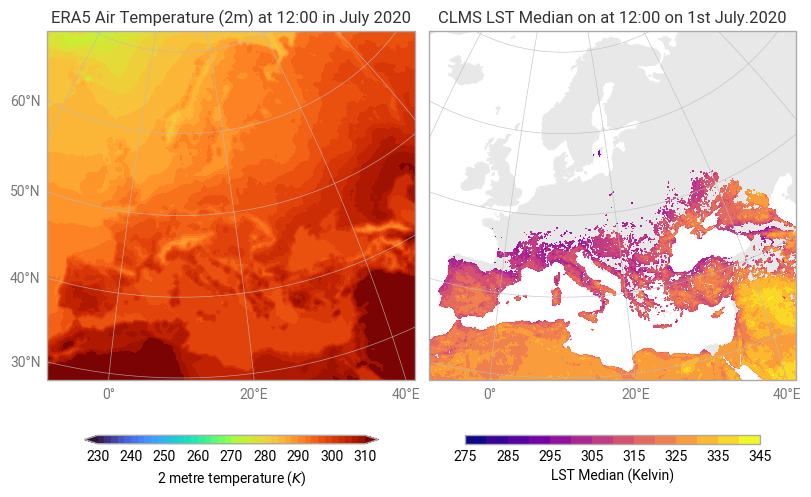

In [8]:
figure = earthkit.plots.Figure(rows=1, columns=2)

dt_map = figure.add_map(domain="Europe")
dt_map.plot(ds_era5[11], units="kelvin")
dt_map.legend(location="bottom")
dt_map.title("ERA5 Air Temperature (2m) at 12:00 in July 2020")


eum_map = figure.add_map(domain="Europe")
eum_map.plot(ds_clms[59], units="kelvin")
eum_map.legend(location="bottom")
eum_map.title("CLMS LST Median on at 12:00 on 1st July.2020")

figure.land()
figure.gridlines()

figure.show()


### 3.2 Plotting two different datasets side by side for different geographical regions

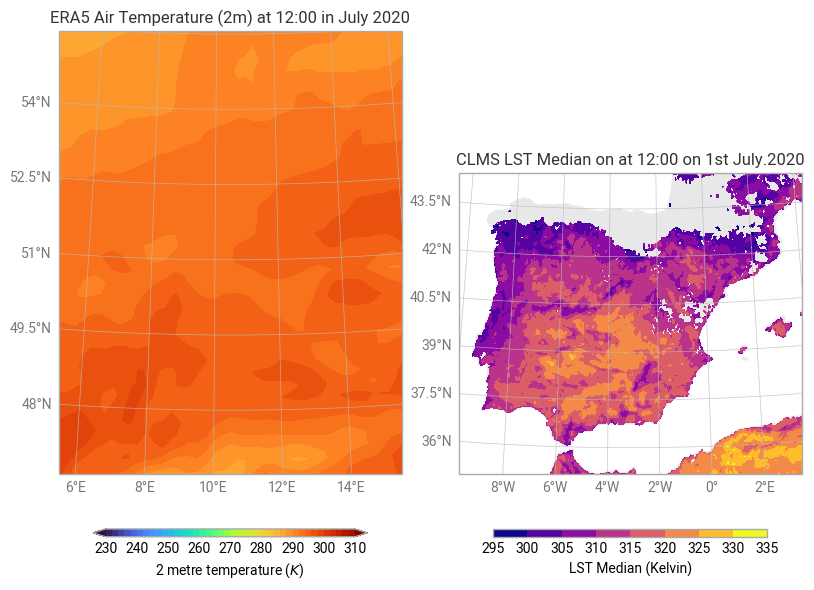

In [9]:
figure = earthkit.plots.Figure(rows=1, columns=2)

dt_map = figure.add_map(domain="Germany")
dt_map.plot(ds_era5[11], units="kelvin")
dt_map.legend(location="bottom")
dt_map.title("ERA5 Air Temperature (2m) at 12:00 in July 2020")


eum_map = figure.add_map(domain="Spain")
eum_map.plot(ds_clms[59], units="kelvin")
eum_map.legend(location="bottom")
eum_map.title("CLMS LST Median on at 12:00 on 1st July.2020")

figure.land()
figure.gridlines()

figure.show()


### 3.3 Plot each record of a dataset in a subplot

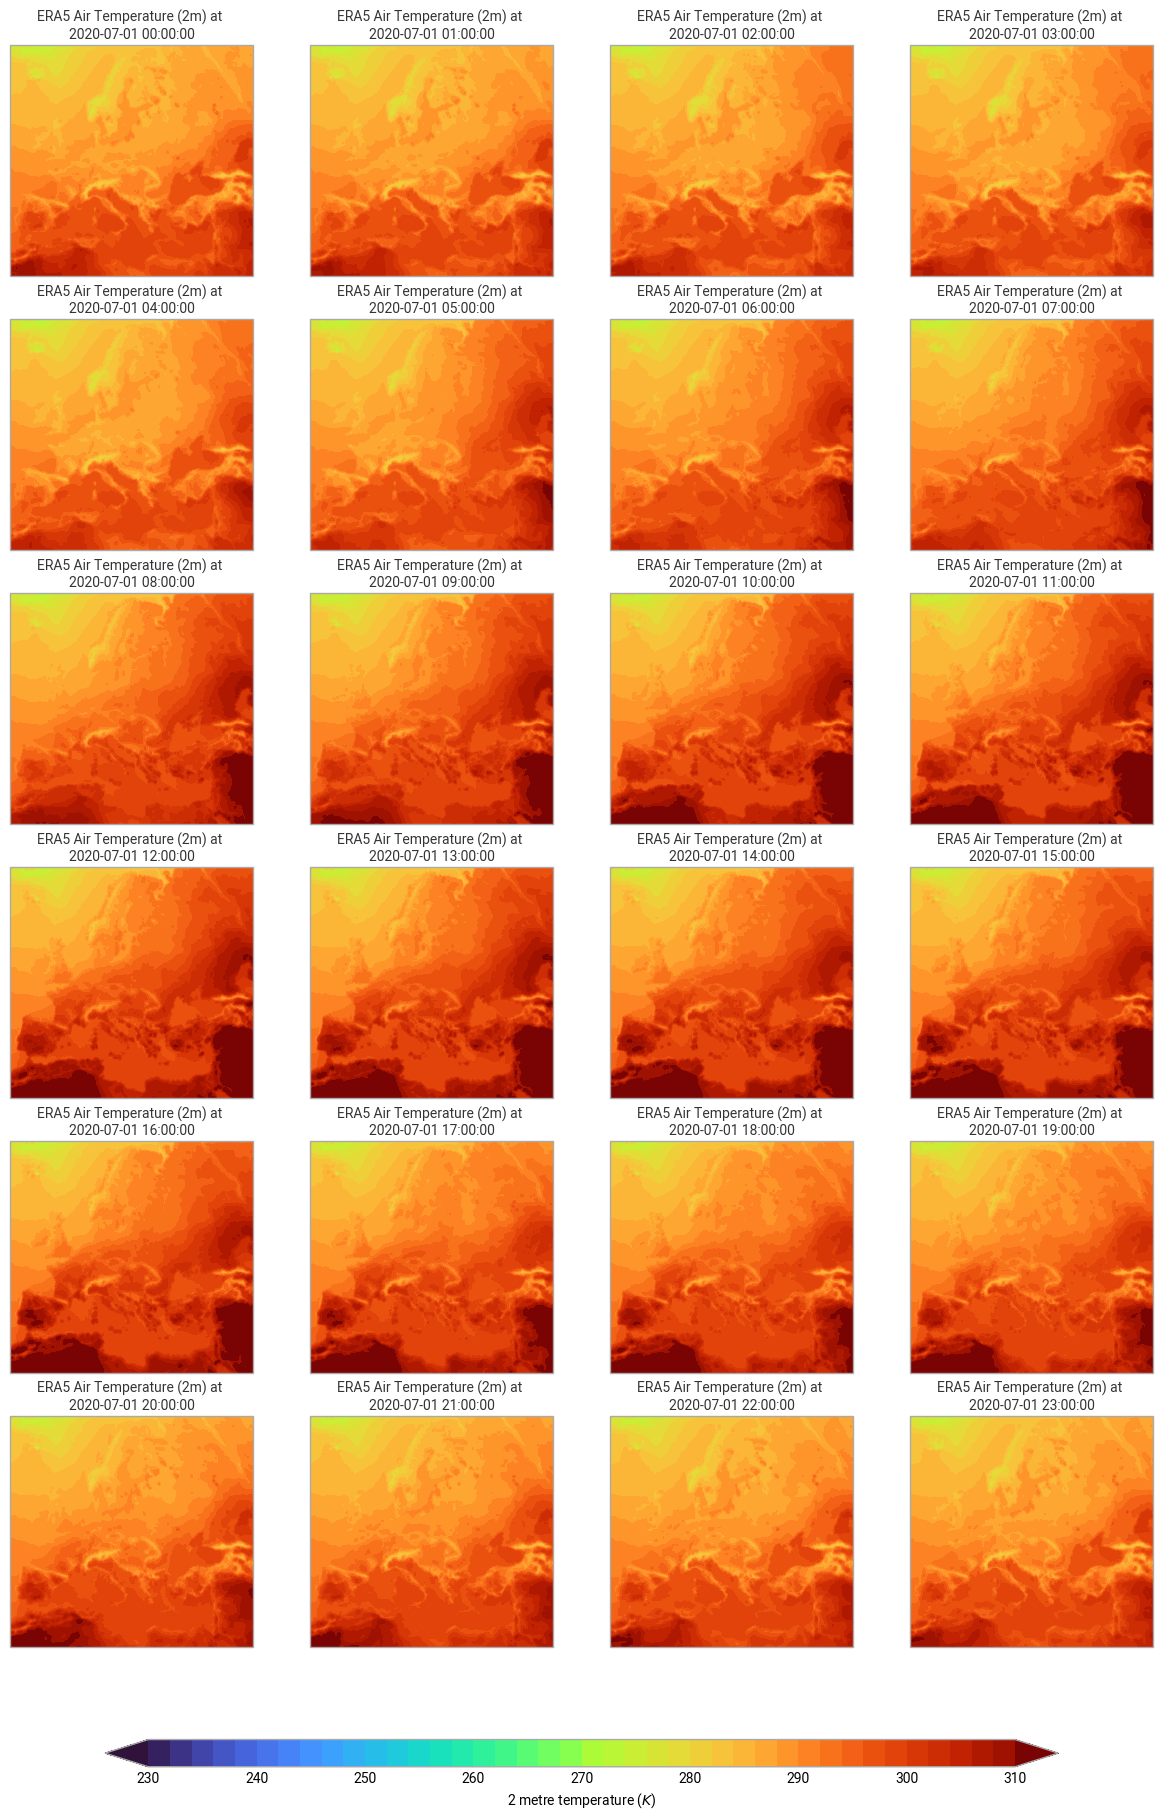

In [10]:
figure = earthkit.plots.Figure(size=(12, 18), rows=6, columns=4)


for i in range(len(ds_era5.ls())):
    dt_map = figure.add_map(domain="Europe")
    dt_map.plot(ds_era5[i], units="kelvin")
    date = str(ds_era5[i].slices[0].value.strftime("%Y-%m-%d %H:%M:%S"))
    dt_map.title("ERA5 Air Temperature (2m) at \n"+date, fontsize=10)
figure.legend(location="bottom")

## 4. Take home messages

- With the Earthkit WEkEO plugin, datasets from different Copernicus services are accessed through the same interface.
- earthkit-plots can plot several datasets side by side, for the same or for different regions, and each record of a dataset in its own subplot.

## 5. Next steps

<font color="#138D75">**Congratulations, you have downloaded and visualized different Copernicus datasets!**</font>

As a next step you can check out the **xCube Viewer** tutorials and notebooks to explore how you can visualize datacubes such as the one created in a graphical User interface and share it with others through a virtual machine. 

For more information on the Earthkit WEkEO Plugin, take a look at the documentation (<a href="https://earthkit-data.readthedocs.io/en/latest/examples/wekeo.html#" target="_blank">Documentation</a>). 

Other notebooks on the use of Earthkit with WEkEO datasets will follow soon and will be available in the <a href="https://notebooks.prod.wekeo2.eu/" target="_blank">Jupyter Catalogue</a>. In the meantime, check out the remaining notebooks in the <a href="https://notebooks.prod.wekeo2.eu/" target="_blank">Jupyter Catalogue</a> to get a feel on the many different datasets you can find on WEkEO, of which many can be now accessed through the Earthkit Plugin!

<hr>

[View on GitHub](https://github.com/wekeo) | 
[Visit WEkEO](https://wekeo.copernicus.eu) | [Run Notebooks on the WEkEO Workspace](https://jupyterhub.prod.wekeo2.eu/) | 
[Contact helpdesk for support](mailto:support@wekeo.eu)